In [2]:
words = open('names.txt','r').read().splitlines()

In [3]:
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [4]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
charset = sorted(set("".join(words)))
stoi = {s:i+1 for i,s in enumerate(charset)}
stoi['.'] = 0

itos = {i:s for s,i in stoi.items()}

In [6]:
b = torch.zeros((27,27),dtype=torch.int32)
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        x,y = stoi[ch1],stoi[ch2]
        b[x][y] += 1


(-0.5, 26.5, 26.5, -0.5)

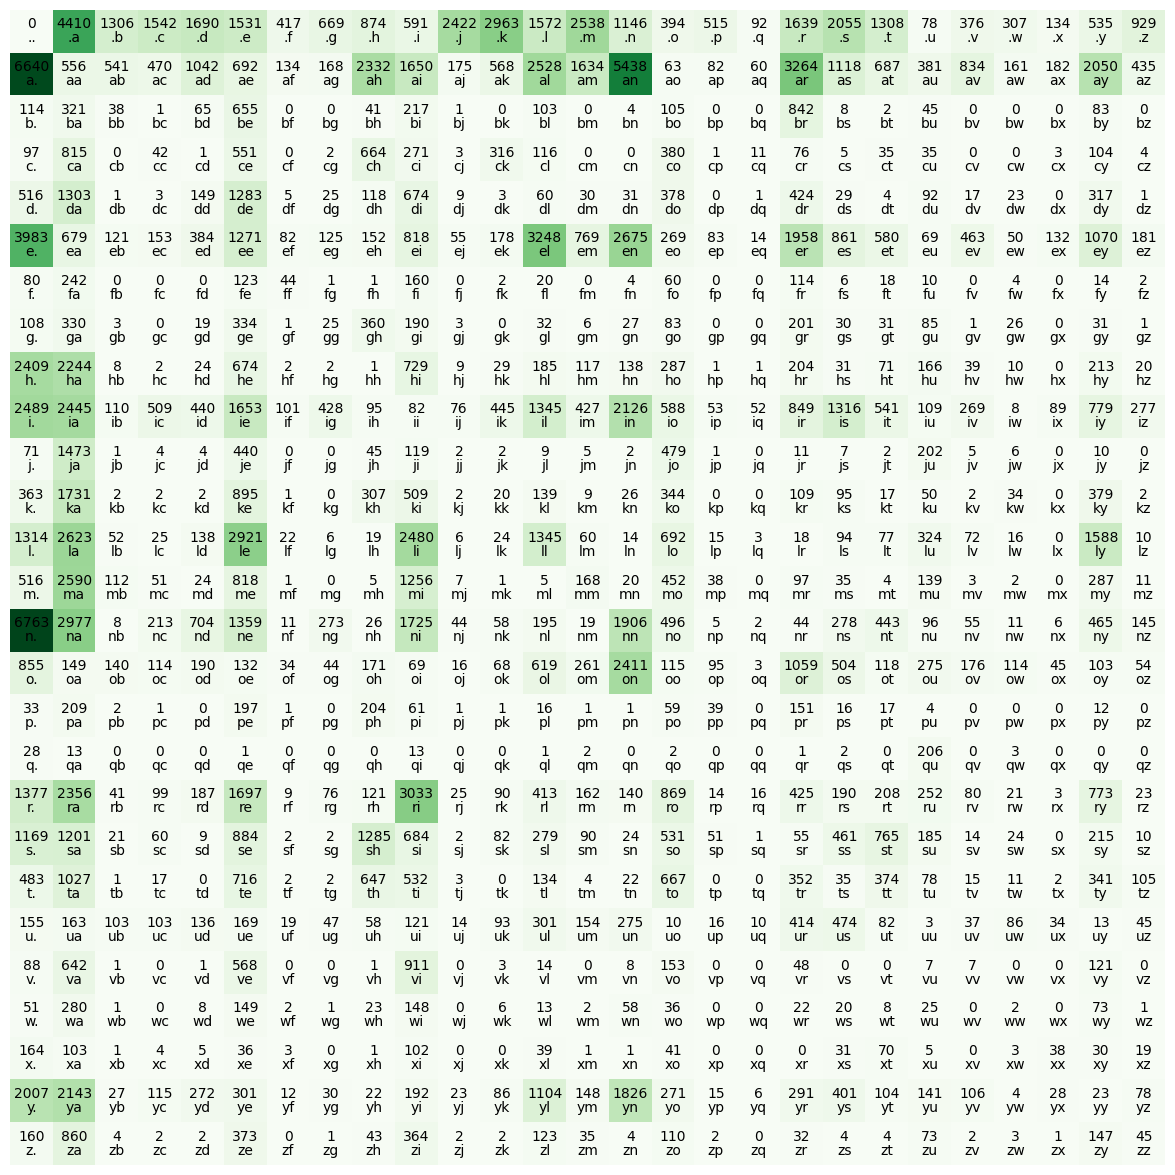

In [7]:
plt.figure(figsize=(15,15))
plt.imshow(b,cmap='Greens')
for i in range(27):
    for j in range(27):
        label = itos[i]+itos[j]
        plt.text(j,i,label,ha='center',va='top')
        plt.text(j,i,b[i][j].item(),ha='center',va='bottom')
plt.axis('off')

In [8]:
P = b.float()
P /= P.sum(1,keepdim=True)

In [9]:
# g = torch.Generator().manual_seed(2147483647)
# ix = torch.multinomial(p,num_samples=1,replacement=True,generator=g)
# itos[ix.item()]

In [10]:
g = torch.Generator().manual_seed(2147483647)
ix=0
count = 0
names = []
name = ''
while count<10:
    p=P[ix]
    ix = torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
    name += itos[ix]
    if ix ==0:
        names.append(name)
        name = ''
        count += 1
    
names


['junide.',
 'janasah.',
 'p.',
 'cony.',
 'a.',
 'nn.',
 'kohin.',
 'tolian.',
 'juee.',
 'ksahnaauranilevias.']

In [11]:
log_likelihood = 0.0
n = 0
for w in words:
    w = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(w,w[1:]):
        ix1, ix2 = stoi[ch1], stoi[ch2]
        prob = P[ix1,ix2]
        # print(f'{ch1=},{ch2=},{prob}')
        n+=1
        logprob = torch.log(prob)
        log_likelihood += logprob
nll = -log_likelihood
nll /= n
print(f'{nll=}')

nll=tensor(2.4541)


## Prediction using one neuron and Bigram

In [12]:
xs, ys = [], []
for w in words:
    w = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(w,w[1:]):
        ix1, ix2 = stoi[ch1], stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

In [13]:
xs= torch.tensor(xs)
ys= torch.tensor(ys)

In [14]:
import torch.nn.functional as F
xenc = F.one_hot(xs,num_classes=27).float()

In [15]:
W = torch.randn((27,27),requires_grad=True,generator=g)

In [16]:
for _ in range(500):
    logits = xenc@W
    counts = logits.exp()
    probs = counts/counts.sum(1,keepdim=True)
    loss = -probs[torch.arange(len(ys)),ys].log().mean() +  0.01*(W**2).mean()
    W.grad = None
    loss.backward()
    W.data += -10*W.grad
    print(loss.data.item())


3.66935133934021
3.5955989360809326
3.528517246246338
3.4673800468444824
3.4116265773773193
3.3607571125030518
3.314300775527954
3.27181077003479
3.232869863510132
3.1970977783203125
3.164156675338745
3.1337504386901855
3.105621337890625
3.0795445442199707
3.0553231239318848
3.0327820777893066
3.011765480041504
2.992133855819702
2.9737632274627686
2.9565422534942627
2.940373182296753
2.9251677989959717
2.910848379135132
2.897345542907715
2.8845953941345215
2.872542381286621
2.8611342906951904
2.8503246307373047
2.8400702476501465
2.830331563949585
2.8210718631744385
2.8122572898864746
2.8038573265075684
2.7958431243896484
2.7881875038146973
2.7808663845062256
2.773857355117798
2.767139434814453
2.7606935501098633
2.754502058029175
2.748549461364746
2.742820978164673
2.737302541732788
2.7319819927215576
2.7268478870391846
2.7218899726867676
2.717099189758301
2.7124664783477783
2.7079837322235107
2.703643321990967
2.69943904876709
2.695363759994507
2.6914124488830566
2.687579393386841
2.

In [17]:
name = ''
ix = 0
for i in range(5):
    while True:
        ix = torch.tensor([ix])
        xenc = F.one_hot(ix,num_classes=27).float()
        logits = xenc@W
        counts = logits.exp()
        probs = counts/counts.sum(1,keepdims=True)
        ix = torch.multinomial(probs,replacement=True,num_samples=1,generator=g).item()
        if ix ==0:
            print(name)
            name = ''
            ix = 0
            break
        name += itos[ix]

kevietamleleronakin
lalastan
tcyonanisemyn
lewlixin
kadarekan


## Prediction using a block size of 3

In [18]:
# block_size = 3
# X = []
# y = []
# for w in words:
#     context = [0] * block_size
#     for ch in w+'.':
#         ix = stoi[ch]
#         y.append(ix)
#         X.append(context)
#         context = context[1:] + [ix]
# X = torch.tensor(X)
# y = torch.tensor(y)

In [19]:
import random
random.shuffle(words)
block_size = 3
def build_dataset(words):
    X = []
    y = []
    for w in words:
        context = [0] * block_size
        for ch in w+'.':
            ix = stoi[ch]
            y.append(ix)
            X.append(context)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    y = torch.tensor(y)
    return X, y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

X_train, y_train = build_dataset(words[:n1])
X_test, y_test = build_dataset(words[n1:n2])
X_val, y_val = build_dataset(words[n2:])

In [20]:
n_hidden = 200

C = torch.randn((27,10))
w1 = torch.randn((block_size*C.shape[1],n_hidden)) / (30**(1/2))
w2 = torch.randn((n_hidden,27)) / (n_hidden**(1/2))
b2 = torch.zeros(27) / (n_hidden**(1/2))

bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))
parameters = [C,w1,w2,b2,bngain,bnbias]

In [21]:
for p in parameters:
    p.requires_grad = True

In [22]:
for i in range(0,50001):
    ix = torch.randint(0,len(X_train),(64,))
    emb = C[X_train[ix]]
    h_pre = emb.view(-1,w1.shape[0])@w1
    h_pre = bngain*((h_pre - h_pre.mean(0,keepdims=True))/h_pre.std(0,keepdims=True)) + bnbias
    h = torch.tanh(h_pre)
    logits = h@w2 + b2
    loss = F.cross_entropy(logits,y_train[ix])
    if i % 5000 == 0:
        print(f'interation={i}, loss={loss.item()}')
        losses = 0
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data += -0.01*p.grad


interation=0, loss=3.3756613731384277
interation=5000, loss=2.3275105953216553
interation=10000, loss=2.428537368774414
interation=15000, loss=2.1033897399902344
interation=20000, loss=2.4259281158447266
interation=25000, loss=2.352994203567505
interation=30000, loss=2.326869010925293
interation=35000, loss=2.6057584285736084
interation=40000, loss=2.305819034576416
interation=45000, loss=2.402390718460083
interation=50000, loss=2.1021652221679688


In [23]:
with torch.no_grad():
    emb = C[X_train]
    h_pre = torch.tanh(emb.view(-1,w1.shape[0])@w1)
    bnmean = h_pre.mean(0,keepdims=True)
    bnstd = h_pre.std(0,keepdims=True)

In [24]:
emb = C[X_train]
h_pre = torch.tanh(emb.view(-1,w1.shape[0])@w1)
h_pre = bngain*((h_pre - bnmean)/bnstd) + bnbias
h = torch.tanh(h_pre)
logits = h@w2 + b2
loss = F.cross_entropy(logits,y_train)
loss

tensor(2.2236, grad_fn=<NllLossBackward0>)

In [25]:
emb = C[X_val]
h_pre = torch.tanh(emb.view(-1,w1.shape[0])@w1)
h_pre = bngain*((h_pre - bnmean)/bnstd) + bnbias
h = torch.tanh(h_pre)
logits = h@w2 + b2
loss = F.cross_entropy(logits,y_val)
loss

tensor(2.2429, grad_fn=<NllLossBackward0>)

In [42]:
name = ''
context = [0]*block_size
for i in range(20):
    while True:
        emb = C[torch.tensor([context])]
        h_pre = torch.tanh(emb.view(-1,w1.shape[0])@w1)
        h_pre = bngain*((h_pre - bnmean)/bnstd) + bnbias
        h = torch.tanh(h_pre)
        logits = h@w2 + b2
        counts = logits.exp()
        probs = counts/counts.sum(1,keepdims=True)
        ix = torch.multinomial(probs,replacement=True,num_samples=1).item()
        context = context[1:]+[ix]
        if ix ==0:
            print(name)
            name = ''
            ix = 0
            break
        name += itos[ix]

avin
srislenyyel
karia

honya
dyohnik
graddn
shan
xun
edellarkelanomia
davie
nd
chariina

namial
nlisse
dyon
kyre
ger



In [29]:
ix

0